# Reconnaissance d'expressions faciales avec le Deep Learning

## Partie 1 — Recherche, compréhension et préparation des données

L'objectif du projet est de construire progressivement un modèle capable
de reconnaître différentes expressions faciales à partir d'images de visages.

### Dataset choisi : FER-2013

FER-2013 est un dataset de reconnaissance d'expressions faciales créé dans
le cadre du challenge "Challenges in Representation Learning" de l'ICML 2013.

Les images sont des visages en niveaux de gris de taille 48 × 48 pixels.

Les sept classes sont :

- Enervé 
- Degouté
- effrayé 
- Joyeux
- triste
- Surpris
- neutre 

Source originale : ICML 2013 Facial Expression Recognition Challenge.

Pour ce projet, les données sont téléchargées depuis le miroir Kaggle
`msambare/fer2013`.

In [1]:
from pathlib import Path 

import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image
import pandas as pd 

import tensorflow as tf 
import kagglehub


In [2]:
print("TensorFlow :", tf.__version__)

TensorFlow : 2.21.0


In [3]:
# Détermination de la racine du projet

PROJECT_ROOT = Path.cwd()

# Si le notebook s'exécute depuis /notebooks
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "fer2013"

print("Projet :", PROJECT_ROOT)
print("Dataset :", DATA_DIR)

Projet : c:\Users\User\facial-expression-recognition
Dataset : c:\Users\User\facial-expression-recognition\data\fer2013


In [4]:
if not DATA_DIR.exists():
    print("Téléchargement de FER-2013...")

    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)

    kagglehub.dataset_download(
        "msambare/fer2013",
        output_dir=str(DATA_DIR)
    )

    print("Téléchargement terminé.")
else:
    print("Le dataset est déjà présent.")

Téléchargement de FER-2013...


100%|██████████| 60.3M/60.3M [00:04<00:00, 15.6MB/s]

Extracting files...


Téléchargement terminé.


In [5]:
train_dir = DATA_DIR / "train"
test_dir = DATA_DIR / "test"

print("Train :", train_dir.exists())
print("Test  :", test_dir.exists())

Train : True
Test  : True


In [6]:
classes = sorted([
    directory.name
    for directory in train_dir.iterdir()
    if directory.is_dir()
])

classes

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [7]:
records = []

for split_name, split_dir in {
    "train": train_dir,
    "test": test_dir
}.items():

    for class_dir in sorted(split_dir.iterdir()):

        if not class_dir.is_dir():
            continue

        image_count = len(list(class_dir.glob("*")))

        records.append({
            "split": split_name,
            "class": class_dir.name,
            "images": image_count
        })

class_distribution = pd.DataFrame(records)

class_distribution

,split,class,images
0,train,angry,3995
1,train,disgust,436
2,train,fear,4097
3,train,happy,7215
4,train,neutral,4965
5,train,sad,4830
6,train,surprise,3171
7,test,angry,958
8,test,disgust,111
9,test,fear,1024


In [8]:
sample_image_path = next(train_dir.rglob("*.jpg"))

with Image.open(sample_image_path) as img:
    print("Taille :", img.size)
    print("Mode :", img.mode)
    print("Format :", img.format)

Taille : (48, 48)
Mode : L
Format : JPEG


### Visualisation des différentes expressions

Afin de mieux comprendre le jeu de données, nous affichons plusieurs exemples
pour chacune des sept classes.

Cette visualisation permet également d'observer la variabilité des visages
au sein d'une même expression.

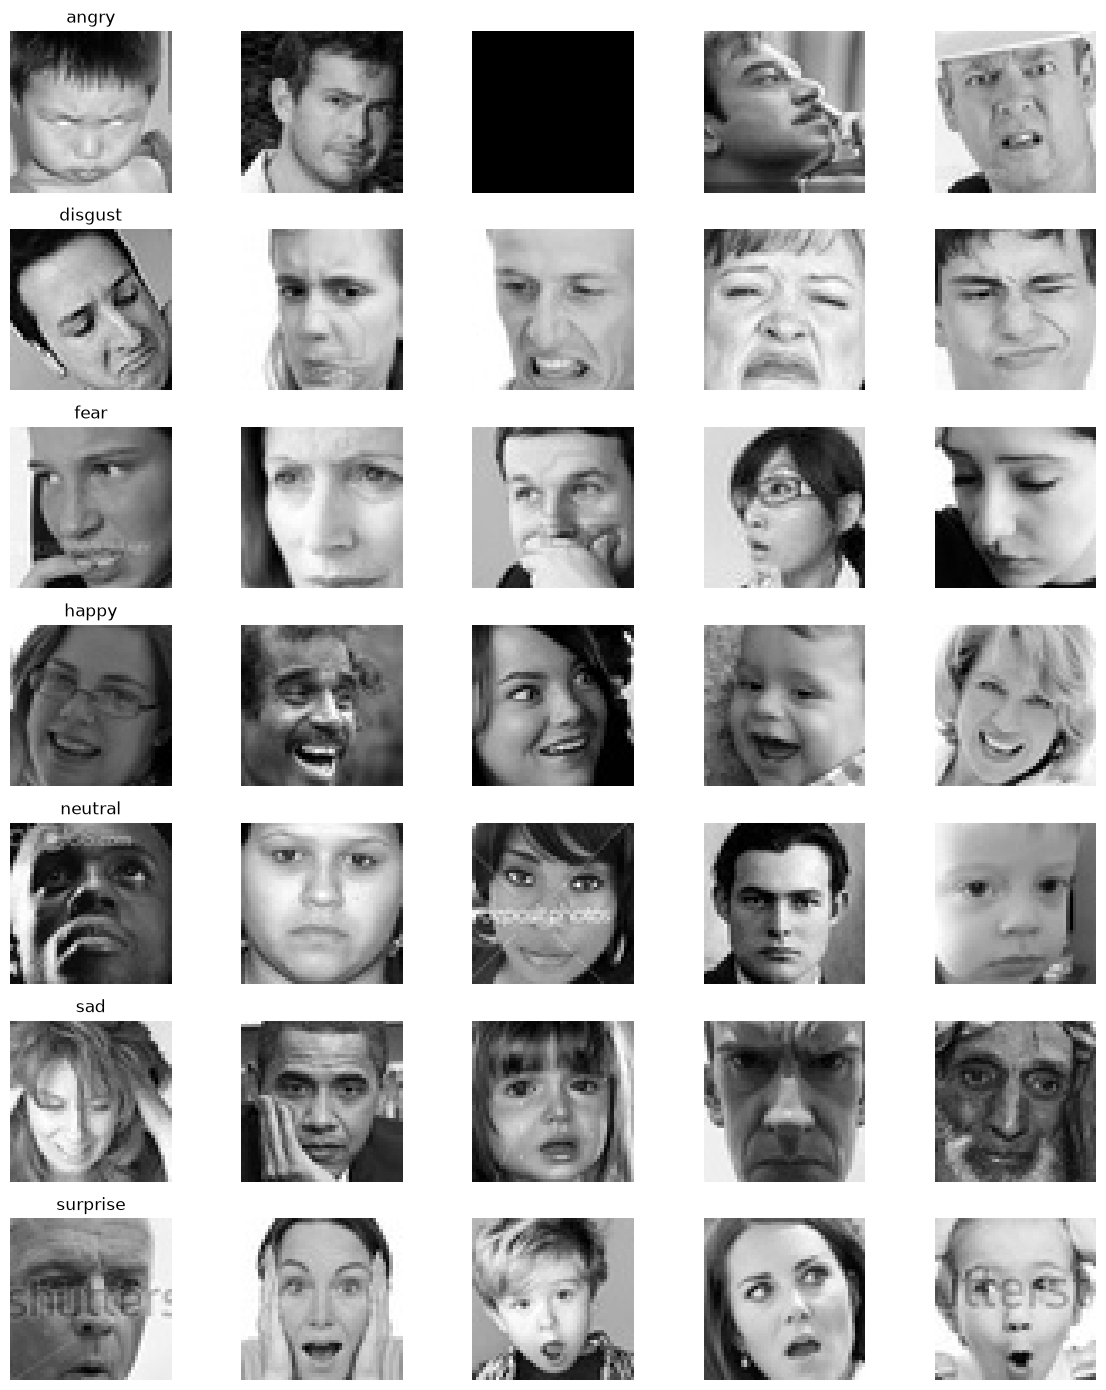

In [9]:
fig, axes = plt.subplots(
    nrows=len(classes),
    ncols=5,
    figsize=(12, 14)
)

for row, class_name in enumerate(classes):

    class_dir = train_dir / class_name
    image_paths = list(class_dir.glob("*.jpg"))[:5]

    for col, image_path in enumerate(image_paths):

        image = Image.open(image_path)

        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(class_name)

plt.tight_layout()
plt.show()

In [10]:
train_distribution = class_distribution[
    class_distribution["split"] == "train"
].copy()

train_distribution

,split,class,images
0,train,angry,3995
1,train,disgust,436
2,train,fear,4097
3,train,happy,7215
4,train,neutral,4965
5,train,sad,4830
6,train,surprise,3171


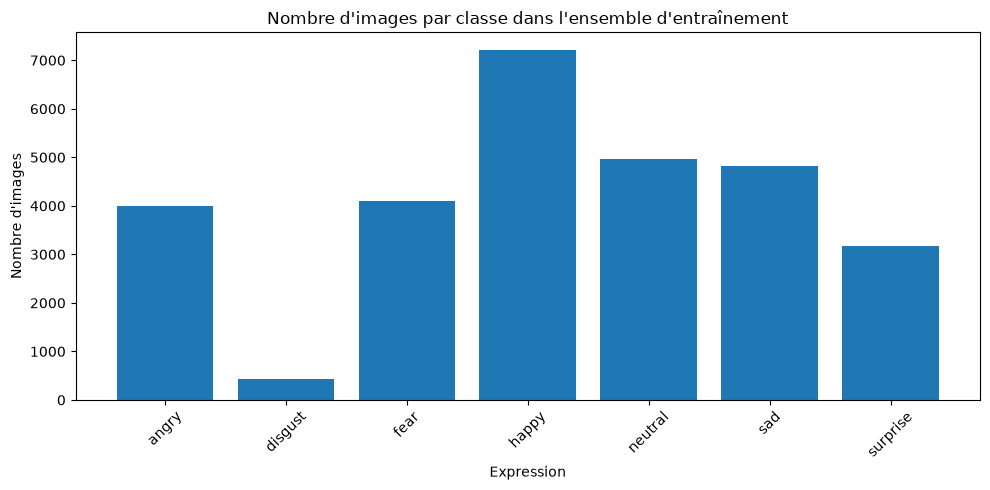

In [11]:
plt.figure(figsize=(10, 5))

plt.bar(
    train_distribution["class"],
    train_distribution["images"]
)

plt.title("Nombre d'images par classe dans l'ensemble d'entraînement")
plt.xlabel("Expression")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
max_images = train_distribution["images"].max()
min_images = train_distribution["images"].min()

imbalance_ratio = max_images / min_images

print("Classe la plus représentée :", max_images, "images")
print("Classe la moins représentée :", min_images, "images")
print(f"Ratio de déséquilibre : {imbalance_ratio:.2f}")

Classe la plus représentée : 7215 images
Classe la moins représentée : 436 images
Ratio de déséquilibre : 16.55


### Analyse de la distribution des classes

La distribution des images n'est pas parfaitement équilibrée entre les
différentes expressions.

Certaines classes sont davantage représentées que d'autres, ce qui peut
influencer l'apprentissage du modèle. Une classe contenant peu d'exemples
risque notamment d'être plus difficile à apprendre.

Il sera donc important de ne pas évaluer le modèle uniquement avec
l'accuracy globale. Une matrice de confusion et des métriques par classe
seront également étudiées lors de l'évaluation du modèle.

In [13]:
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64
SEED = 42

In [14]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.


In [15]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [16]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 7178 files belonging to 7 classes.


In [17]:
class_names = train_dataset.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [18]:
NUM_CLASSES = len(class_names)

print("Nombre de classes :", NUM_CLASSES)

Nombre de classes : 7


In [19]:
for images, labels in train_dataset.take(1):

    print("Shape des images :", images.shape)
    print("Shape des labels :", labels.shape)

    print()
    print("Premiers labels :", labels[:10].numpy())

Shape des images : (64, 48, 48, 1)
Shape des labels : (64,)

Premiers labels : [5 3 3 5 2 3 3 3 5 3]


In [20]:
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

In [21]:
train_dataset = train_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

validation_dataset = validation_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

test_dataset = test_dataset.map(
    lambda images, labels: (
        normalization_layer(images),
        labels
    )
)

In [22]:
for images, labels in train_dataset.take(1):

    print("Pixel minimum :", images.numpy().min())
    print("Pixel maximum :", images.numpy().max())

Pixel minimum : 0.0
Pixel maximum : 1.0


### Préparation des données

Les images sont chargées par batch de 64 images.

Le dataset d'entraînement original est séparé en deux parties :

- 80 % pour l'entraînement ;
- 20 % pour la validation.

Le dossier de test fourni par FER-2013 est conservé séparément et ne sera
utilisé que pour l'évaluation finale du modèle.

Les images sont en niveaux de gris et possèdent une dimension de
48 × 48 pixels avec un seul canal.

Les valeurs des pixels, initialement comprises entre 0 et 255, sont
normalisées entre 0 et 1 afin de faciliter l'apprentissage du réseau.

Les expressions sont représentées par des labels entiers correspondant aux
différentes classes du dataset.

In [23]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

# Partie 2 — Construction d'un modèle de référence

Avant de construire un réseau convolutif, nous allons entraîner un réseau
de neurones dense simple.

Ce modèle servira de baseline afin de disposer d'un point de comparaison
avec le CNN développé dans la suite du projet.

L'architecture utilisée est :

Image → Flatten → Dense + ReLU → Dense + Softmax

In [24]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

In [25]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295,943 (1.13 MB)

 Trainable params: 295,943 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

### Architecture du modèle de référence

L'image d'entrée possède une dimension de 48 × 48 pixels avec un seul canal,
soit 2304 valeurs.

La couche `Flatten` transforme l'image en un vecteur de 2304 valeurs sans
ajouter de paramètre entraînable.

La première couche Dense contient 128 neurones avec une activation ReLU.
Elle possède :

2304 × 128 + 128 = 295 040 paramètres.

La couche de sortie contient 7 neurones, correspondant aux 7 expressions
faciales du dataset. Elle utilise une activation Softmax afin de produire
une distribution de probabilités entre les différentes classes.

Cette architecture servira de modèle de référence avant la construction
d'un CNN.

In [26]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Entraînement du modèle de référence

Le modèle de référence est entraîné sur les données d'entraînement et évalué
à chaque époque sur l'ensemble de validation.

Nous utilisons dans un premier temps 10 époques afin d'observer le comportement
du modèle sans chercher à optimiser ses performances.

In [27]:
EPOCHS = 10

baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10


c:\Users\User\facial-expression-recognition\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


359/359 ━━━━━━━━━━━━━━━━━━━━ 117s 316ms/step - accuracy: 0.2662 - loss: 1.8050 - val_accuracy: 0.2959 - val_loss: 1.7380
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.3094 - loss: 1.7217 - val_accuracy: 0.3222 - val_loss: 1.7084
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.3235 - loss: 1.7020 - val_accuracy: 0.3454 - val_loss: 1.6778
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.3368 - loss: 1.6796 - val_accuracy: 0.3412 - val_loss: 1.6848
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.3404 - loss: 1.6733 - val_accuracy: 0.3336 - val_loss: 1.6769
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.3444 - loss: 1.6637 - val_accuracy: 0.3468 - val_loss: 1.6715
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.3465 - loss: 1.6571 - val_accuracy: 0.3442 - val_loss: 1.6594
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 53ms/step - accuracy: 0.3522 - loss: 1.6464 - val_accur

In [28]:
history = baseline_history.history

history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

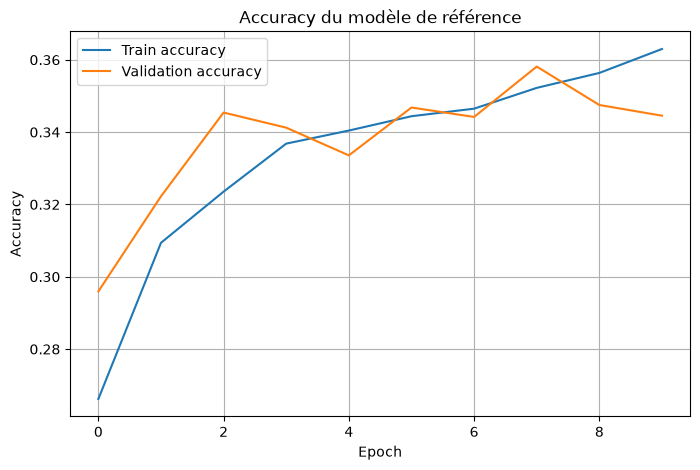

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history["accuracy"], label="Train accuracy")
plt.plot(history["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy du modèle de référence")
plt.legend()
plt.grid()

plt.show()

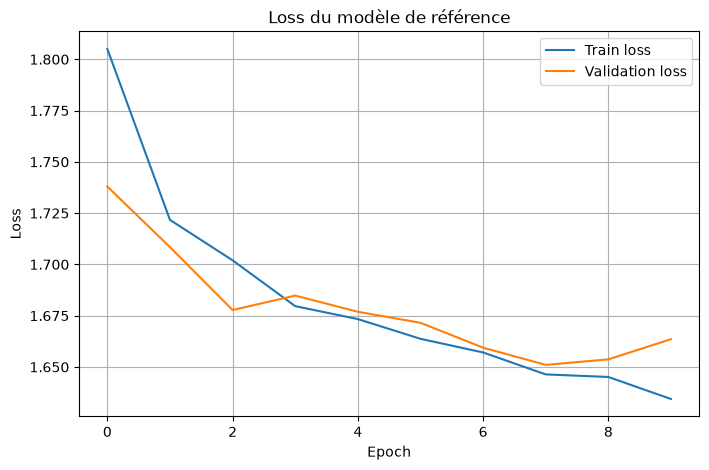

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(history["loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss du modèle de référence")
plt.legend()
plt.grid()

plt.show()

In [31]:
val_loss, val_accuracy = baseline_model.evaluate(validation_dataset)

print(f"Validation loss : {val_loss:.4f}")
print(f"Validation accuracy : {val_accuracy:.4f}")

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3445 - loss: 1.6635
Validation loss : 1.6635
Validation accuracy : 0.3445


### Analyse de l'entraînement du modèle de référence

Au cours des premières époques, l'accuracy augmente sur les ensembles
d'entraînement et de validation tandis que la loss diminue. Le modèle
parvient donc bien à apprendre certaines caractéristiques des données.

Les performances restent cependant limitées, avec une accuracy de validation
d'environ 35 %.

À partir des dernières époques, l'accuracy d'entraînement continue de
progresser tandis que l'accuracy de validation stagne puis diminue légèrement.
De même, la loss de validation recommence à augmenter alors que la loss
d'entraînement continue de diminuer.

Ce comportement indique un début de surapprentissage.

Ce résultat constitue notre modèle de référence. Nous chercherons ensuite à
améliorer les performances grâce à un réseau convolutif (CNN), mieux adapté
à l'analyse de la structure spatiale des images.

In [32]:
baseline_val_loss = val_loss
baseline_val_accuracy = val_accuracy